In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kartik2112/fraud-detection")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fraud-detection' dataset.
Path to dataset files: /kaggle/input/fraud-detection


In [2]:
import os

print(os.listdir(path))

['fraudTest.csv', 'fraudTrain.csv']


In [3]:
import pandas as pd
import os

df = pd.read_csv(os.path.join(path, "fraudTrain.csv"))

In [4]:
df.head()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [5]:
df = df.sample(n=10000, random_state=42).reset_index(drop=True)
df.shape

(10000, 23)

In [6]:
df = df.drop(columns=[
    'Unnamed: 0',
    'trans_date_trans_time',
    'cc_num',
    'first',
    'last',
    'street',
    'trans_num'
])

In [7]:
from sklearn.preprocessing import LabelEncoder

In [8]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   merchant    10000 non-null  int64  
 1   category    10000 non-null  int64  
 2   amt         10000 non-null  float64
 3   gender      10000 non-null  int64  
 4   city        10000 non-null  int64  
 5   state       10000 non-null  int64  
 6   zip         10000 non-null  int64  
 7   lat         10000 non-null  float64
 8   long        10000 non-null  float64
 9   city_pop    10000 non-null  int64  
 10  job         10000 non-null  int64  
 11  dob         10000 non-null  int64  
 12  unix_time   10000 non-null  int64  
 13  merch_lat   10000 non-null  float64
 14  merch_long  10000 non-null  float64
 15  is_fraud    10000 non-null  int64  
dtypes: float64(5), int64(11)
memory usage: 1.2 MB


In [10]:
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

In [11]:
X.shape

(10000, 15)

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [13]:
X_scaled.shape

(10000, 15)

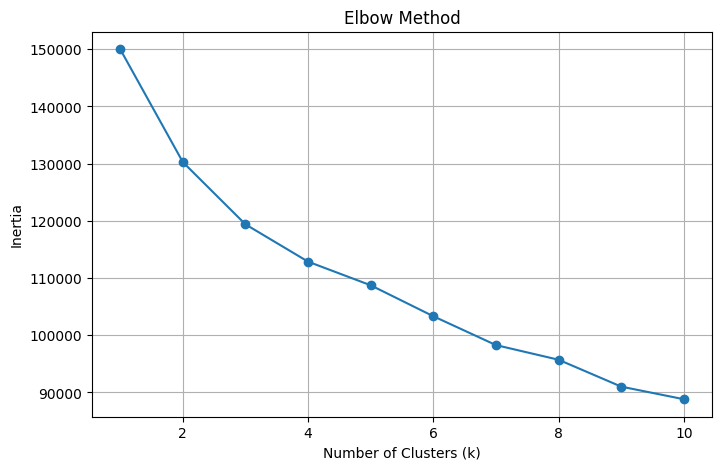

In [14]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

In [15]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

In [16]:
df['Cluster'] = clusters

In [17]:
from sklearn.metrics import silhouette_score

print("Silhouette Score:", silhouette_score(X_scaled, clusters))

Silhouette Score: 0.12722915849700286


In [18]:
from sklearn.metrics import davies_bouldin_score

print("Davies-Bouldin Score:", davies_bouldin_score(X_scaled, clusters))

Davies-Bouldin Score: 2.3097110790854676


In [19]:
from sklearn.metrics import calinski_harabasz_score

print("Calinski-Harabasz Score:", calinski_harabasz_score(X_scaled, clusters))

Calinski-Harabasz Score: 1281.864285283619


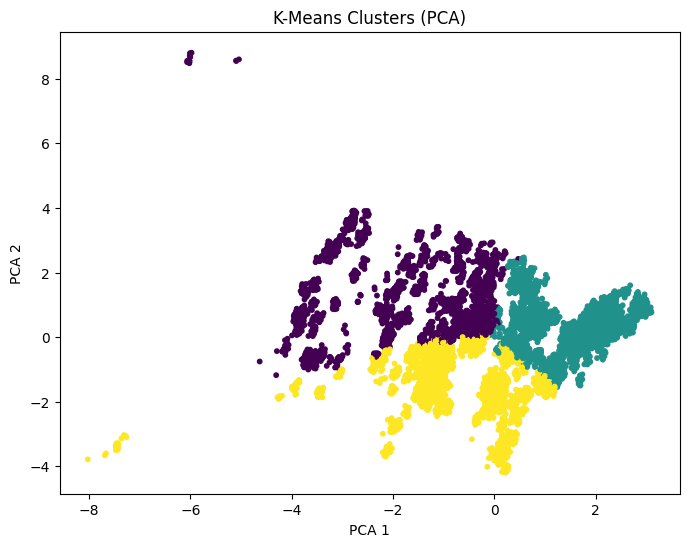

In [20]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis', s=10)
plt.title("K-Means Clusters (PCA)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [22]:
import kagglehub
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# -------------------------
# 1. Load dataset
# -------------------------
path = kagglehub.dataset_download("kartik2112/fraud-detection")

df = pd.read_csv(path + "/fraudTrain.csv")

# -------------------------
# 2. Drop useless columns
# -------------------------
df = df.drop(columns=[
    'Unnamed: 0',
    'trans_date_trans_time',
    'cc_num',
    'first',
    'last',
    'street',
    'trans_num'
])

# -------------------------
# 3. Clean data
# -------------------------
df = df.dropna()

# (اختياري لتسريع)
df = df.sample(20000, random_state=42)

# -------------------------
# 4. Split features
# -------------------------
X = df.drop('is_fraud', axis=1)

# -------------------------
# 5. Encoding
# -------------------------
X = pd.get_dummies(X, drop_first=True)

# -------------------------
# 6. Scaling
# -------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------
# 7. Test different K values
# -------------------------
print("🔍 Testing Best K Values:\n")

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

    print(f"k = {k} | Silhouette Score = {score}")

# -------------------------
# 8. Best K
# -------------------------
best_k = range(2, 11)[silhouette_scores.index(max(silhouette_scores))]

print("\n🔥 Best K =", best_k)
print("⭐ Best Silhouette Score =", max(silhouette_scores))

Using Colab cache for faster access to the 'fraud-detection' dataset.
🔍 Testing Best K Values:

k = 2 | Silhouette Score = -0.04677279851761893
k = 3 | Silhouette Score = -0.03554371119384043
k = 4 | Silhouette Score = -0.08620419099359615
k = 5 | Silhouette Score = -0.052730304148553966
k = 6 | Silhouette Score = -0.06493597081637711
k = 7 | Silhouette Score = -0.061764690199417965
k = 8 | Silhouette Score = -0.06652445111734358


KeyboardInterrupt: 

In [23]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# =========================
# 1. Load Data
# =========================
df = pd.read_csv("/kaggle/input/fraud-detection/fraudTrain.csv")

# =========================
# 2. Drop unnecessary columns
# =========================
df = df.drop(columns=[
    'Unnamed: 0',
    'trans_date_trans_time',
    'cc_num',
    'first',
    'last',
    'street',
    'trans_num',
    'dob'
])

# =========================
# 3. One-Hot Encoding
# =========================
df = pd.get_dummies(df, drop_first=True)

# =========================
# 4. Sample data (important for speed)
# =========================
df = df.sample(n=50000, random_state=42)

# =========================
# 5. Split features (NO label for clustering)
# =========================
X = df.drop('is_fraud', axis=1)

# =========================
# 6. Scaling
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================
# 7. PCA (dimensionality reduction)
# =========================
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

# =========================
# 8. K-Means
# =========================
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_pca)

# =========================
# 9. Evaluation
# =========================
sil = silhouette_score(X_pca, labels)
db = davies_bouldin_score(X_pca, labels)
ch = calinski_harabasz_score(X_pca, labels)

print("Silhouette Score:", sil)
print("Davies-Bouldin Score:", db)
print("Calinski-Harabasz Score:", ch)

# =========================
# 10. Try different K (optional but strong for assignment)
# =========================
print("\nTesting different K values:")
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_pca)
    score = silhouette_score(X_pca, lbl)
    print(f"K={k} | Silhouette={score}")

Silhouette Score: 0.13223389108757772
Davies-Bouldin Score: 2.1481137146087996
Calinski-Harabasz Score: 6471.725443442381

Testing different K values:
K=2 | Silhouette=0.15892639993961302
K=3 | Silhouette=0.13223389108757772
K=4 | Silhouette=0.1420378572132399
K=5 | Silhouette=0.15802503080391317
K=6 | Silhouette=0.16077396755584067
K=7 | Silhouette=0.16411129345916847


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# =========================
# 1. Scaling
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================
# 2. Try K from 8 to 15
# =========================
ks = range(8, 16)

sil_scores = []
db_scores = []
ch_scores = []
inertias = []

print("Testing K from 8 to 15:\n")

for k in ks:
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=50,
        max_iter=500,
        random_state=42
    )

    labels = kmeans.fit_predict(X_scaled)

    sil = silhouette_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)

    sil_scores.append(sil)
    db_scores.append(db)
    ch_scores.append(ch)
    inertias.append(kmeans.inertia_)

    print(f"K={k} | Silhouette={sil:.4f} | DB={db:.4f} | CH={ch:.2f}")

# =========================
# 3. Best K (Silhouette)
# =========================
best_k = ks[np.argmax(sil_scores)]

print("\nBest K (based on Silhouette):", best_k)

# =========================
# 4. Plot results
# =========================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(list(ks), sil_scores, marker='o')
plt.title("Silhouette Score (K > 7)")
plt.xlabel("K")
plt.ylabel("Silhouette Score")

plt.subplot(1,2,2)
plt.plot(list(ks), inertias, marker='o')
plt.title("Elbow Method (Inertia)")
plt.xlabel("K")
plt.ylabel("Inertia")

plt.tight_layout()
plt.show()

Testing K from 8 to 15:

